Data Exploration and Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
# Load the CSV file
df = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')

In [ ]:
# Set the display option to show all columns
pd.set_option('display.max_columns', None)

In [ ]:
# Display the column names
print("Column Names:", df.columns)

Column Names: Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [ ]:
pd.set_option('display.max.columns', None)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14247 entries, 0 to 14246
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            14247 non-null  int64  
 1   type            14247 non-null  object 
 2   amount          14247 non-null  float64
 3   nameOrig        14247 non-null  object 
 4   oldbalanceOrg   14246 non-null  float64
 5   newbalanceOrig  14246 non-null  float64
 6   nameDest        14246 non-null  object 
 7   oldbalanceDest  14246 non-null  float64
 8   newbalanceDest  14246 non-null  float64
 9   isFraud         14246 non-null  float64
 10  isFlaggedFraud  14246 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 1.2+ MB


In [ ]:
df.shape

(14247, 11)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,14247.0,5.037131e+00,2.463112e+00,1.00,2.00,6.000,7.0000,8.00
amount,14247.0,1.118848e+05,2.805152e+05,2.39,4585.13,12869.360,121891.7050,10000000.00
oldbalanceOrg,14246.0,7.937369e+05,2.016693e+06,0.00,0.00,20415.000,138495.6450,12930418.44
newbalanceOrig,14246.0,8.107136e+05,2.059984e+06,0.00,0.00,8216.325,129417.2875,13010502.78
oldbalanceDest,14246.0,8.411336e+05,2.528174e+06,0.00,0.00,0.000,264142.6525,20937587.49
newbalanceDest,14246.0,1.147629e+06,3.151706e+06,0.00,0.00,0.000,277515.0500,25330272.63
isFraud,14246.0,5.475221e-03,7.379448e-02,0.00,0.00,0.000,0.0000,1.00
isFlaggedFraud,14246.0,0.000000e+00,0.000000e+00,0.00,0.00,0.000,0.0000,0.00


In [ ]:
import numpy as np  # Import the NumPy library and give it the alias 'np'

len_not_fraud = len(df['isFraud'][df.isFraud == 0])
len_is_fraud = len(df['isFraud'][df.isFraud == 1])

arr = np.array([len_not_fraud, len_is_fraud])  # Now you can use 'np'
labels = ['Not Fraudulent', 'Fraudulent']
print(f"Total No. of Non-Fraudulent Cases: {len_not_fraud}")
print(f"Total No. Fraudulent Cases: {len_is_fraud}")

Total No. of Non-Fraudulent Cases: 14168
Total No. Fraudulent Cases: 78


In [ ]:
# Check for missing values in the target column
print("Missing values in 'isFraud':", df['isFraud'].isnull().sum())

Missing values in 'isFraud': 1


In [ ]:
# Drop rows with missing target values
df = df.dropna(subset=['isFraud'])

In [ ]:
# Prepare features and target
X = df[['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
y = df['isFraud']

In [ ]:
# Convert categorical feature 'type' to dummy variables
X = pd.get_dummies(X, columns=['type'])

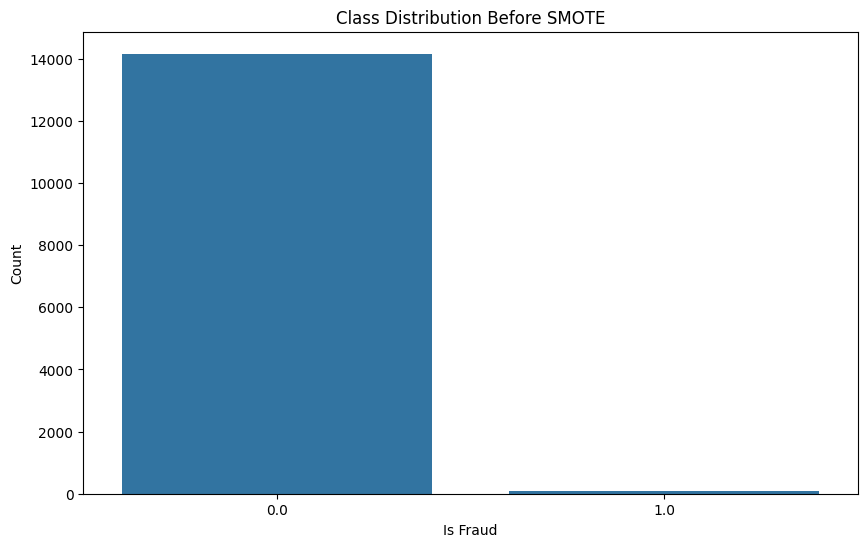

In [ ]:
# Plot the class distribution before SMOTE
plt.figure(figsize=(10, 6))
sns.countplot(x=y)
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

In [ ]:
# Apply SMOTE to the features and target
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
# Verify the number of samples in each class after SMOTE
print("Class distribution after SMOTE:\n", y_resampled.value_counts())

Class distribution after SMOTE:
 isFraud
0.0    14168
1.0    14168
Name: count, dtype: int64


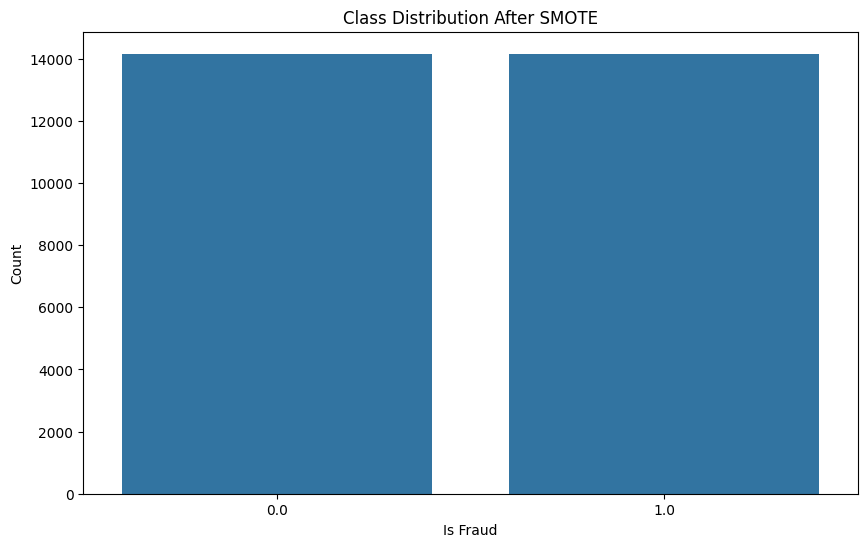

In [ ]:
# Plot the class distribution after SMOTE
plt.figure(figsize=(10, 6))
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

In [ ]:
# Split the resampled data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Instantiate KNN Classifier
knn = KNeighborsClassifier()

In [ ]:
# Train the model
model_knn = knn.fit(X_train, y_train)

# Predict on the test set
knn_pred = model_knn.predict(X_test)

In [ ]:
# Evaluate the model
print("Classification Report:\n", classification_report(y_test, knn_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.97      0.98      4232
         1.0       0.97      0.99      0.98      4269

    accuracy                           0.98      8501
   macro avg       0.98      0.98      0.98      8501
weighted avg       0.98      0.98      0.98      8501



In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, knn_pred)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[4116  116]
 [  30 4239]]


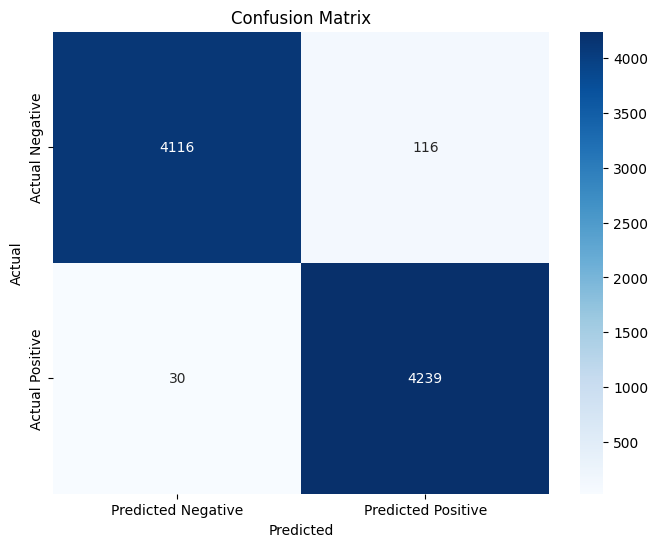

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Checking unique values in predictions
predictions_knn = pd.DataFrame(knn_pred, columns=['Predictions'])
print("Unique values in predictions:\n", predictions_knn['Predictions'].value_counts())

Unique values in predictions:
 Predictions
1.0    4355
0.0    4146
Name: count, dtype: int64


In [ ]:
# Confusion matrix as a DataFrame
confusion_matrix_knn = pd.DataFrame(conf_matrix,
                                    index=['Actual Negative', 'Actual Positive'],
                                    columns=['Predicted Negative', 'Predicted Positive'])
print("Confusion Matrix DataFrame:\n", confusion_matrix_knn)

Confusion Matrix DataFrame:
                  Predicted Negative  Predicted Positive
Actual Negative                4116                 116
Actual Positive                  30                4239


In [ ]:
# Define function for correlation matrix plot
def plotCorrelationMatrix(df, graphWidth):
    df = df.select_dtypes(include=[np.number])  # Keep only numeric columns
    df = df.dropna(axis='columns')  # Drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]]  # Keep columns with more than 1 unique value
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(figsize=(graphWidth, graphWidth), dpi=80)
    corrMat = plt.matshow(corr, fignum=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title('Correlation Matrix', fontsize=15)
    plt.show()

Plotting per column distribution...


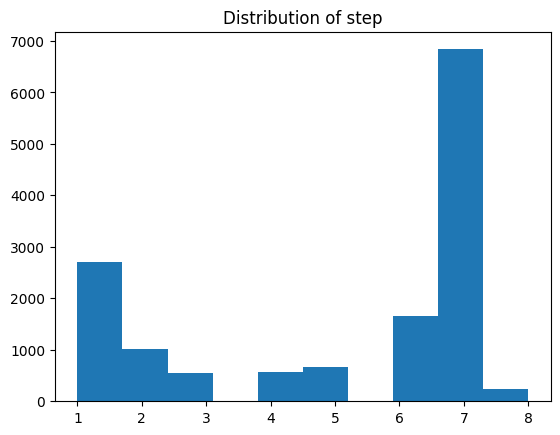

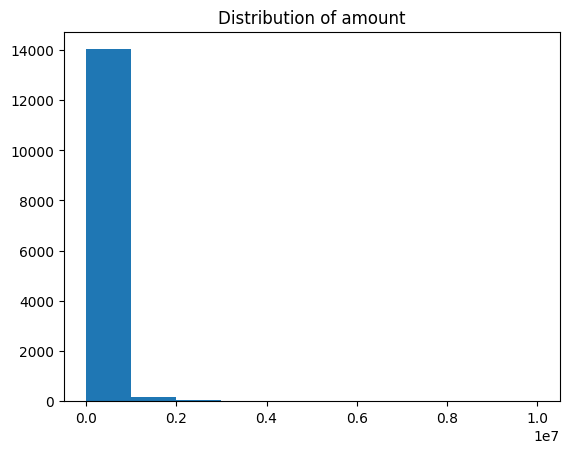

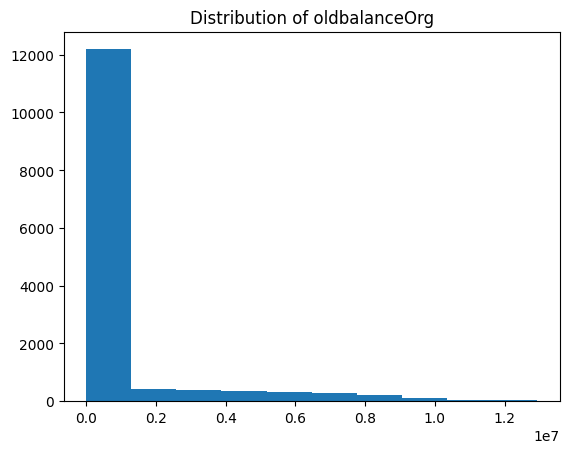

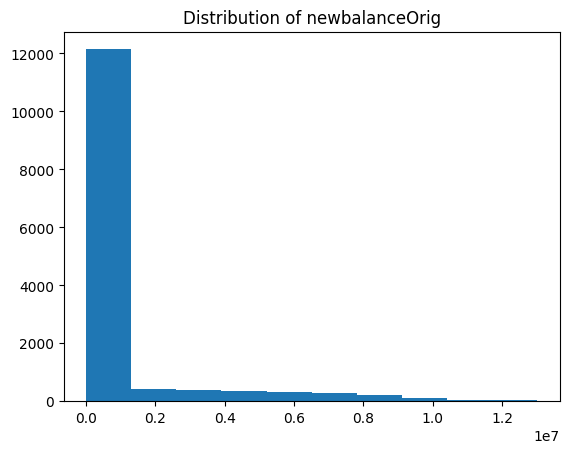

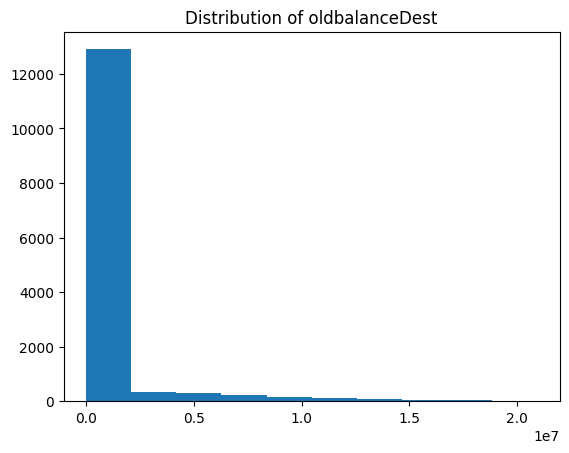

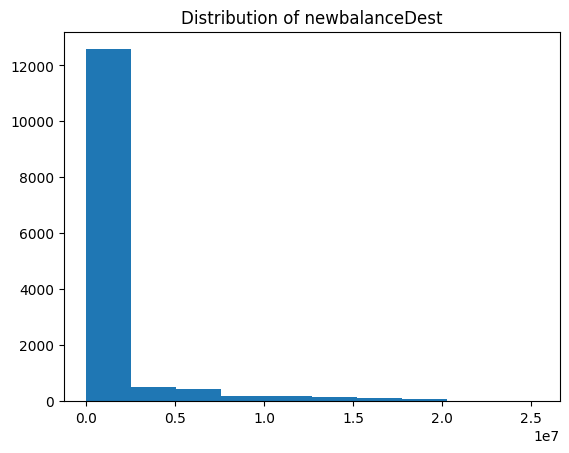

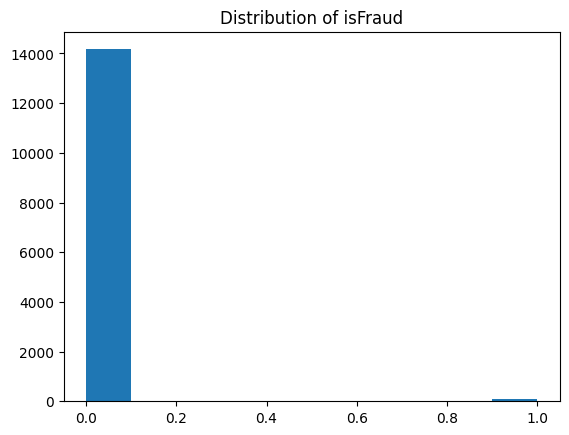

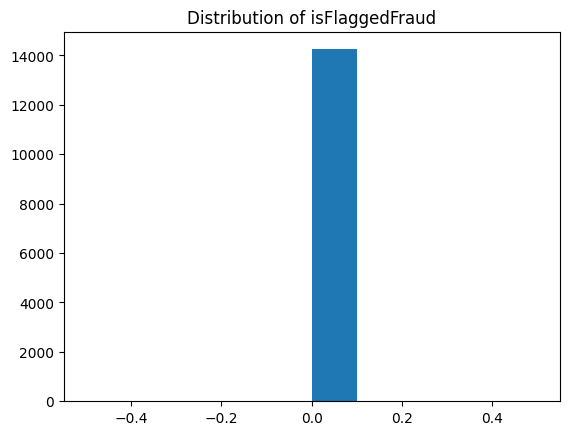

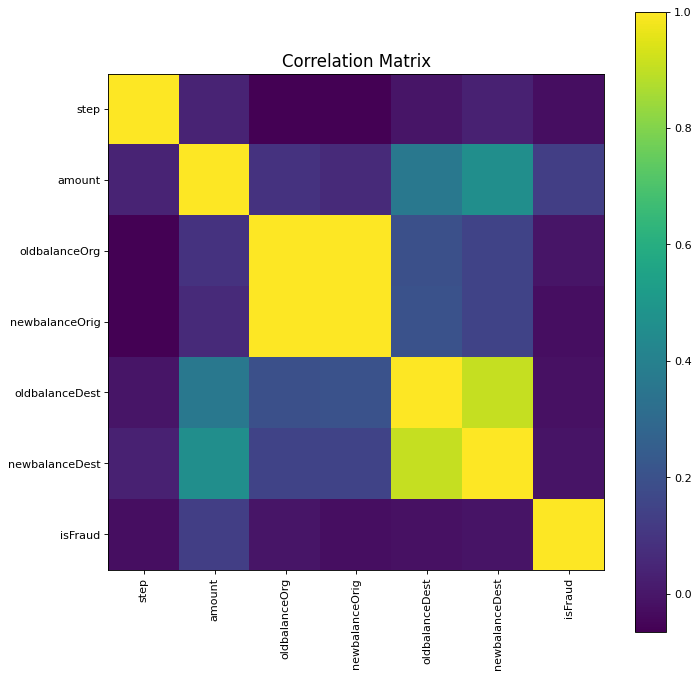

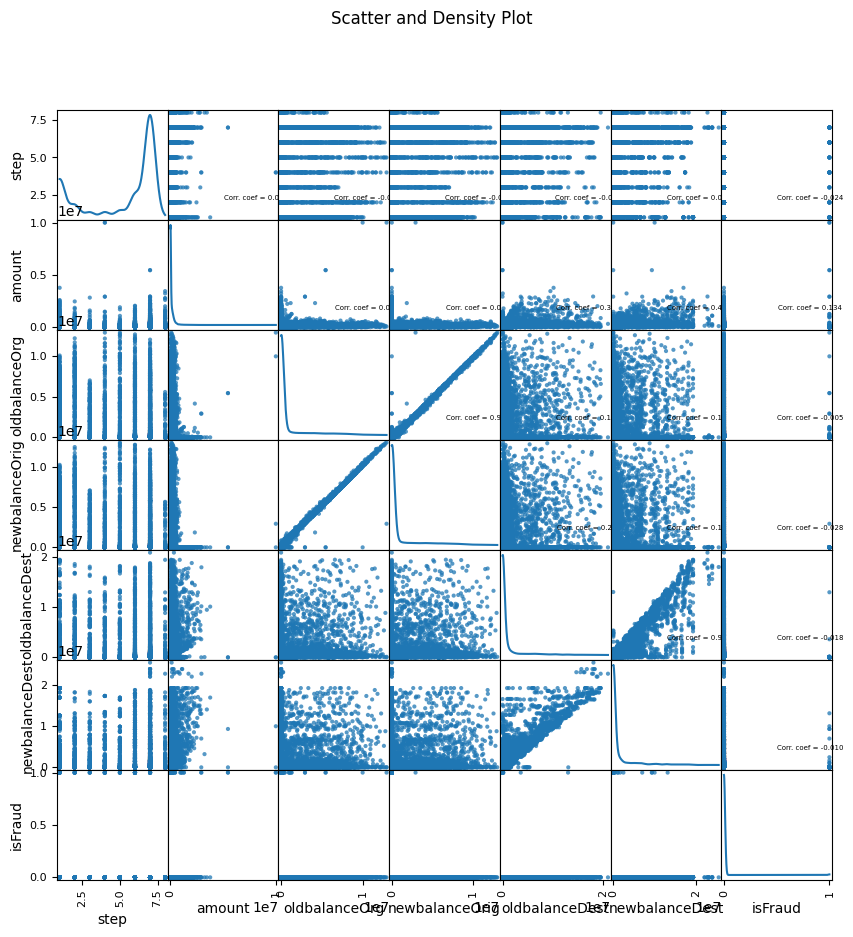

In [ ]:
# Define function for scatter matrix plot
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include=[np.number])  # Keep only numerical columns
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]  # Keep columns with more than 1 unique value
    columnNames = list(df)
    if len(columnNames) > 10:  # Reduce number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k=1)):
        ax[i, j].annotate(f'Corr. coef = {corrs[i, j]:.3f}', (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()
# Example usage of additional plots
plotPerColumnDistribution(df, 10, 5)
plotCorrelationMatrix(df, 10)
plotScatterMatrix(df, 10, 5)


In [ ]:
# Calculate and print percentage of fraudulent transactions
percent_fraud = len(df[df.isFraud == 1]) / len(df[df.isFraud == 0]) * 100
print(f"Percentage of Fraudulent Transactions in the Dataset: {percent_fraud:.2f}%")

Percentage of Fraudulent Transactions in the Dataset: 0.55%


In [ ]:
# Display unique values in the 'type' column
print("Unique values in 'type':", df['type'].unique())

Unique values in 'type': ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [ ]:
df["type"].nunique()

5

In [ ]:
df["type"].unique()


array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0




## Model Building and Evaluation

### Feature Engineering
The "type" column in the dataset contains categorical data namely:
- PAYMENT
- TRANSFER
- CASH_OUT
- DEBIT
- CASH_IN

We will be using label encoding to convert the categorical data to numerical datatype.

In [ ]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [ ]:
data = df.copy(deep = True)

In [ ]:
# get all categorical columns in the dataframe
catCols = [col for col in data.columns if data[col].dtype=="O"]

from sklearn.preprocessing import LabelEncoder

lb_make = LabelEncoder()

for item in catCols:
    data[item] = lb_make.fit_transform(data[item])


In [ ]:
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0
2,1,4,181.00,181.0,0.00,0.0,0.0,1.0,0.0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0


The type column has now been converted from a categorical datatype to numerical datatype using label encoding.

- PAYMENT = 3
- TRANSFER = 4
- CASH_OUT = 1
- DEBIT = 2
- CASH_IN = 0

In [ ]:
# The function below will be used to evaluate different metrics of the algorithms used here.
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred):
    print("Accuracy Score: ", accuracy_score(y_test, y_pred))
    print("Precision Score: ", precision_score(y_test, y_pred))
    print("Recall Score: ", recall_score(y_test, y_pred))
    print("F1 Score: ", f1_score(y_test, y_pred))
    print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))


    df = {'y_Actual': y_test, 'y_Predicted': y_pred}

    df1 = pd.DataFrame(df, columns = ['y_Actual','y_Predicted'])

    clf_confusion_matrix = pd.crosstab(df['y_Predicted'], df['y_Actual'], rownames = ['Predicted'], colnames=['Actual'])

    sns.heatmap(clf_confusion_matrix, annot=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

X = data.drop('isFraud', axis=1)
y = data.isFraud


# setting up testing and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=27)

Unique predicted labels:  [0.]
Accuracy Score:  0.993542953396968
Precision Score:  0.0
Recall Score:  0.0
F1 Score:  0.0
Confusion Matrix:  [[3539    0]
 [  23    0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


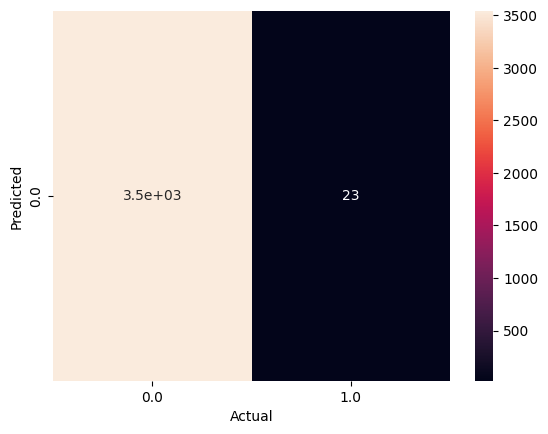

In [ ]:
# DummyClassifier to predict only target 0
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

# checking unique labels
print('Unique predicted labels: ', (np.unique(dummy_pred)))

# checking accuracy
evaluate_model(y_test, dummy_pred)

As we can see the Dummy classifier accurately predicts non-fraudulent transactions with an accuracy of 99.8% but that is not our focus. We need to be able to accurately predict fraudulent transactions.

### Logistic Regression
Logistic regression estimates the probability of an event occurring, such as voted or didn't vote, based on a given dataset of independent variables. Since the outcome is a probability, the dependent variable is bounded between 0 and 1.

In [ ]:
from sklearn.impute import SimpleImputer

# Create an imputer object with a strategy (e.g., mean, median, most_frequent)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on X_train
imputer.fit(X_train)

# Transform both X_train and X_test
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)


In [ ]:
X_train.dropna(axis=0, inplace=True)
y_train = y_train[X_train.index]  # Update y_train accordingly


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Example Pipeline with imputation and model fitting
numeric_features = X_train.select_dtypes(include=['number']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ])

# Append classifier to preprocessing pipeline
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', LogisticRegression())])

# Now you can fit the pipeline
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud'],
      dtype='object'))])),
                ('classifier', LogisticRegression())])

Accuracy Score:  0.9839977540707467
Precision Score:  0.24242424242424243
Recall Score:  0.6956521739130435
F1 Score:  0.35955056179775285
Confusion Matrix:  [[3489   50]
 [   7   16]]
Accuracy Score:  0.9839977540707467
Precision Score:  0.24242424242424243
Recall Score:  0.6956521739130435
F1 Score:  0.35955056179775285
Confusion Matrix:  [[3489   50]
 [   7   16]]


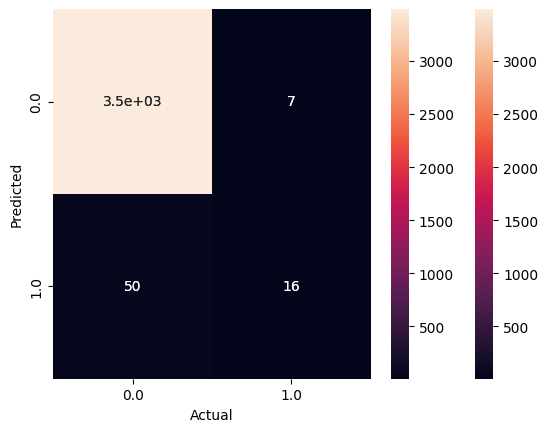

In [ ]:
# Modeling the data as is
# Train model
lr = LogisticRegression()
model1 = lr.fit(X_train, y_train)

# Predict on training set
lr_pred = model1.predict(X_test)
evaluate_model(y_test, lr_pred)# ... (Your existing code for model training)

# Generate predictions using the fitted model
lr_pred = clf.predict(X_test)

# Now evaluate the model
evaluate_model(y_test, lr_pred)

In [ ]:
# Checking unique values
predictions = pd.DataFrame(lr_pred)
predictions[0].value_counts()

,count
0,
0.0,3496
1.0,66


In [ ]:
pd.DataFrame(confusion_matrix(y_test, lr_pred))

,0,1
0,3489,50
1,7,16


The Logistic Regression Model performs quite well but the recall score is still very low. More work needs to be done with the dataset.

Decision Tree Classifier

Accuracy Score:  0.9957888826501965
Precision Score:  0.6818181818181818
Recall Score:  0.6521739130434783
F1 Score:  0.6666666666666666
Confusion Matrix:  [[3532    7]
 [   8   15]]


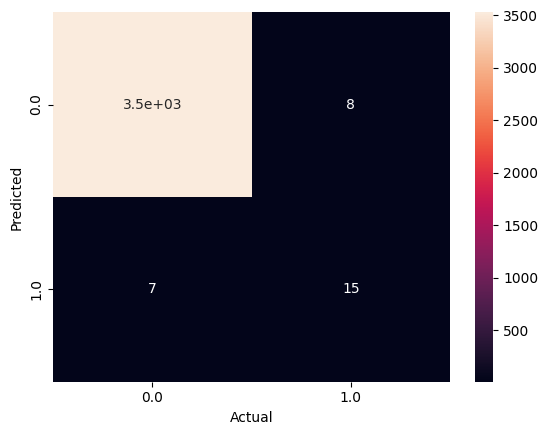

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

# Instantiate Decision Tree Classifier
dt = DecisionTreeClassifier()

# Train model
model_dt = dt.fit(X_train, y_train)

# Predict on test set
dt_pred = model_dt.predict(X_test)

# Evaluate model
evaluate_model(y_test, dt_pred)

# Checking unique values in predictions
predictions_dt = pd.DataFrame(dt_pred)
predictions_dt[0].value_counts()

# Confusion matrix
confusion_matrix_dt = pd.DataFrame(confusion_matrix(y_test, dt_pred))


### Random Forest Classifier

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

Accuracy Score:  0.9971925884334644
Precision Score:  1.0
Recall Score:  0.5652173913043478
F1 Score:  0.7222222222222222
Confusion Matrix:  [[3539    0]
 [  10   13]]


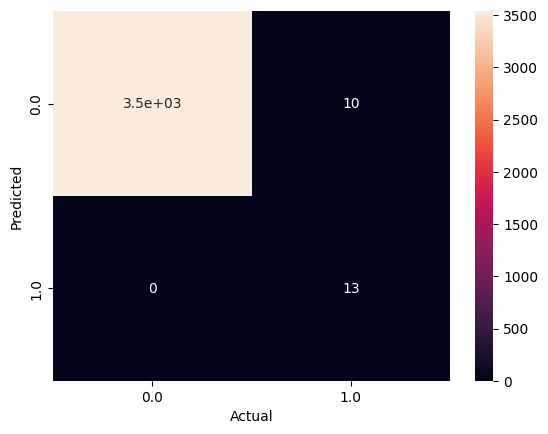

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=10).fit(X_train, y_train)

# predict on test set
rfc_pred = rfc.predict(X_test)

evaluate_model(y_test, rfc_pred)

In [ ]:
# Checking unique values
predictions = pd.DataFrame(rfc_pred)
predictions[0].value_counts()

,count
0,
0.0,3549
1.0,13


We can see that the Random Forest had the best scores so far across different metrics with a recall score of 77% and an F1 score of 86%. The next sections will look at the extreme gradient boosting classifier and gradient boosted tree classifier.

Support Vector Machine (SVM)

Accuracy Score:  0.993542953396968
Precision Score:  0.0
Recall Score:  0.0
F1 Score:  0.0
Confusion Matrix:  [[3539    0]
 [  23    0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


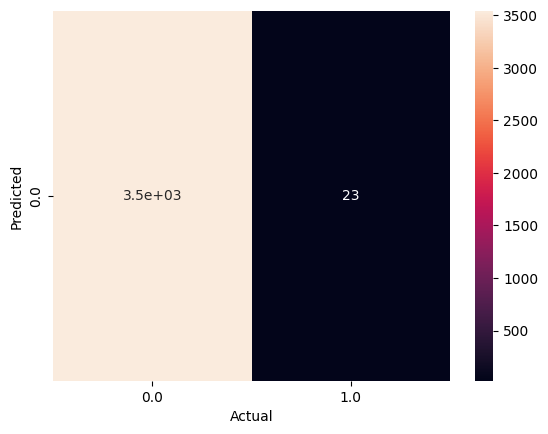

In [ ]:
from sklearn.svm import SVC

# Instantiate SVM Classifier
svm = SVC()

# Train model
model_svm = svm.fit(X_train, y_train)

# Predict on test set
svm_pred = model_svm.predict(X_test)

# Evaluate model
evaluate_model(y_test, svm_pred)

# Checking unique values in predictions
predictions_svm = pd.DataFrame(svm_pred)
predictions_svm[0].value_counts()

# Confusion matrix
confusion_matrix_svm = pd.DataFrame(confusion_matrix(y_test, svm_pred))


K-Nearest Neighbors (KNN)

Accuracy Score:  0.9938236945536215
Precision Score:  0.5714285714285714
Recall Score:  0.17391304347826086
F1 Score:  0.26666666666666666
Confusion Matrix:  [[3536    3]
 [  19    4]]


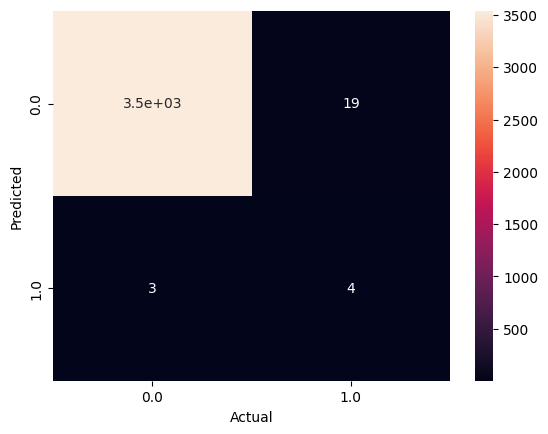

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate KNN Classifier
knn = KNeighborsClassifier()

# Train model
model_knn = knn.fit(X_train, y_train)

# Predict on test set
knn_pred = model_knn.predict(X_test)

# Evaluate model
evaluate_model(y_test, knn_pred)

# Checking unique values in predictions
predictions_knn = pd.DataFrame(knn_pred)
predictions_knn[0].value_counts()

# Confusion matrix
confusion_matrix_knn = pd.DataFrame(confusion_matrix(y_test, knn_pred))


### XGBoost
XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It implements Machine Learning algorithms under the Gradient Boosting framework. It provides a parallel tree boosting to solve many data science problems in a fast and accurate way.

Unlike accuracy, LogLoss is robust in the presence of imbalanced classes. It takes into account the certainty of the prediction. That is the evaluation metric that will be used here.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import log_loss

xgb1 = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.1,
    max_depth=4,
    n_estimators=500,
    subsample=1.0,
    use_label_encoder=False  # Ensure to remove if using newer version
)

eval_set = [(X_test, y_test)]
best_iteration = -1
best_score = float('inf')
early_stopping_rounds = 30
n_estimators = 500
no_improvement_count = 0

for i in range(1, n_estimators + 1):
    xgb1.set_params(n_estimators=i)
    xgb1.fit(X_train, y_train, eval_set=eval_set, verbose=False)

    y_pred = xgb1.predict_proba(X_test)
    score = log_loss(y_test, y_pred)

    if score < best_score:
        best_score = score
        best_iteration = i
        best_model = xgb1
        no_improvement_count = 0
    else:
        no_improvement_count += 1

    if no_improvement_count >= early_stopping_rounds:
        print(f"Early stopping at iteration {best_iteration} with best score {best_score}")
        break

# Use the best model found during early stopping
xgb1 = best_model


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Early stopping at iteration 73 with best score 0.009694075697775178


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy Score:  0.9977540707467715
Precision Score:  0.8571428571428571
Recall Score:  0.782608695652174
F1 Score:  0.8181818181818182
Confusion Matrix:  [[3536    3]
 [   5   18]]


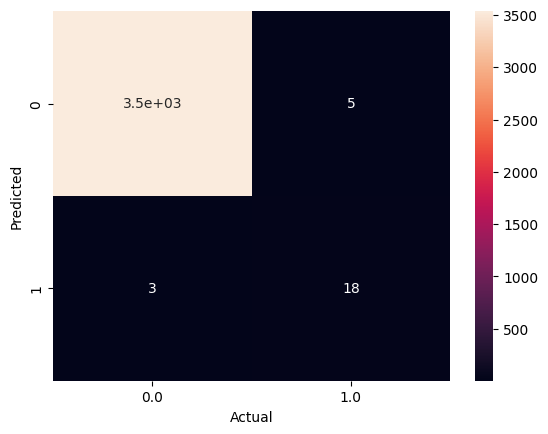

In [ ]:

pred6 = xgb1.predict(X_test)
evaluate_model(y_test, pred6)


In [ ]:
# Checking unique values
predictions = pd.DataFrame(pred6)
predictions[0].value_counts()

,count
0,
0,3541
1,21


In [ ]:
pd.DataFrame(confusion_matrix(y_test, pred6))

,0,1
0,3536,3
1,5,18


### Selecting Our Final Model

The final model used which had the best scores across all metrics will be the random forest classifier.

In [ ]:
import joblib
joblib.dump(rfc, "credit_fraud.pkl")

['credit_fraud.pkl']

In [ ]:
import joblib

# Load the model from the file
model = joblib.load("credit_fraud.pkl")

# Example usage of the loaded model
# Assuming you have a sample input X_sample
# X_sample = [...]  # Replace with your sample input
# prediction = model.predict(X_sample)

def predict(input_data):
    """
    Predict the output using the loaded model.

    Parameters:
    input_data (array-like): Input data for prediction.

    Returns:
    array: Predicted output.
    """
    return model.predict(input_data)

# Example usage:
# if __name__ == "__main__":
#     X_sample = [...]  # Replace with your sample input
#     print(predict(X_sample))


In [ ]:
import pickle

with open('credit_fraud.pkl', 'rb') as file:
    model = pickle.load(file)


In [ ]:
import pickle

# Load the pickle file
with open('/content/credit_fraud.pkl', 'rb') as file:
    loaded_models = pickle.load(file)

# Check the type and content of the loaded object
print(type(loaded_models))
print(loaded_models)


<class 'numpy.ndarray'>
['step' 'type' 'amount' 'oldbalanceOrg' 'newbalanceOrig' 'oldbalanceDest'
 'newbalanceDest' 'isFlaggedFraud']
